# Exam exercise 1: sums of random variables
Alessio Martini 15621707

First of all, we notice that the give distribution is not too-heavy fat-tailed ($\mu = 3$), this means that from the sum $S_N$ we expect normal diffusion and the Central Limit theorem applies.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [13]:
# Funzione per generare N numeri casuali dalla distribuzione fat-tailed
def generate_N_numbers(mu, N):
    u = np.random.uniform(0, 1, N) 
    positive = np.random.choice([-1, 1], size=N)
    return positive*(1 - u)**(-1 / mu)

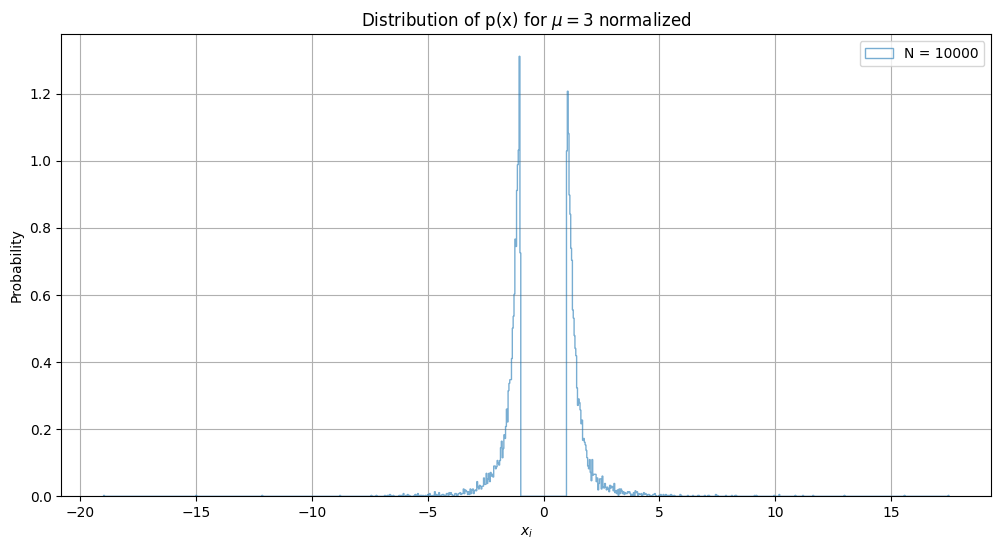

In [23]:
plt.figure(figsize=(12, 6))
        # Genera molte somme S_N per un dato N
N= 10000
mu = 3
values = []
values = generate_N_numbers(mu,N)
        
bins = np.linspace(min(values),max(values), 1000)
plt.hist(values, bins=bins, density=True, alpha=0.6, label=f"N = {N}",histtype='step', stacked=True, fill=False)
    
plt.title(f"Distribution of p(x) for $\\mu = {mu}$ normalized")
plt.xlabel("$x_i$")
plt.ylabel("Probability")
plt.legend()
plt.grid()
plt.show()

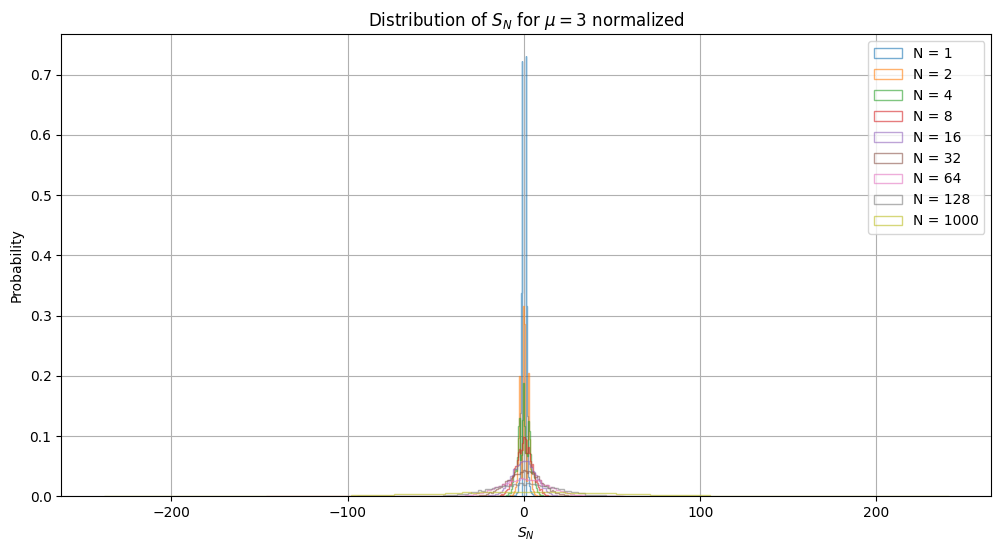

In [36]:
plt.figure(figsize=(12, 6))
        # Genera molte somme S_N per un dato N
samples = 10000
N_values = [1,2,4,8,16,32,64,128,1000]
mu = 3
for N in N_values:
    S_values = []
    for _ in range(samples):
        values = []
        values = generate_N_numbers(mu,N)
        S_values.append(np.sum(values))
            
    bins = np.linspace(min(S_values),max(S_values), 100)
    plt.hist(S_values, bins=bins, density=True, alpha=0.6, label=f"N = {N}",histtype='step', stacked=True, fill=False)
        
plt.title(f"Distribution of $S_N$ for $\\mu = {mu}$ normalized")
plt.xlabel("$S_N$")
plt.ylabel("Probability")
plt.legend()
plt.grid()
plt.show()

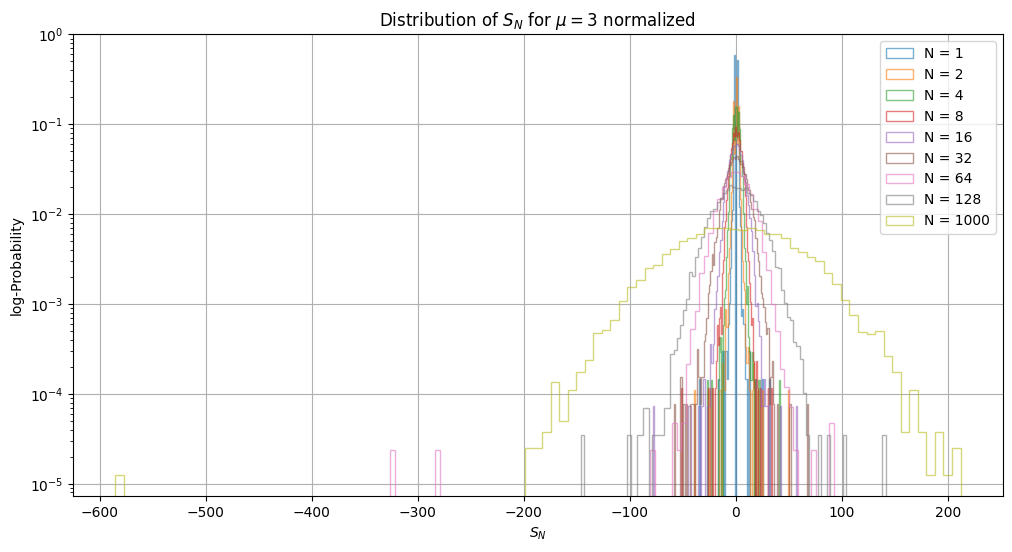

In [38]:
plt.figure(figsize=(12, 6))
        # Genera molte somme S_N per un dato N
samples = 10000
N_values = [1,2,4,8,16,32,64,128,1000]
mu = 3
for N in N_values:
    S_values = []
    for _ in range(samples):
        values = []
        values = generate_N_numbers(mu,N)
        S_values.append(np.sum(values))
            
    bins = np.linspace(min(S_values),max(S_values), 100)
    plt.hist(S_values, bins=bins, density=True, alpha=0.6, label=f"N = {N}",histtype='step', stacked=True, fill=False)
        
plt.title(f"Distribution of $S_N$ for $\\mu = {mu}$ normalized")
plt.xlabel("$S_N$")
plt.ylabel("log-Probability")
plt.yscale("log")

plt.legend()
plt.grid()
plt.show()

1. The value of $\Delta$ is zero, because the distribution is symmetric. This because the distribution for the single elements of the sum is symmetric.

More heuristically, we expect the sum to be measured as many time positive as negative, since the components of the sum are as many time positive as negative.

2. plot on logarithmic axes:

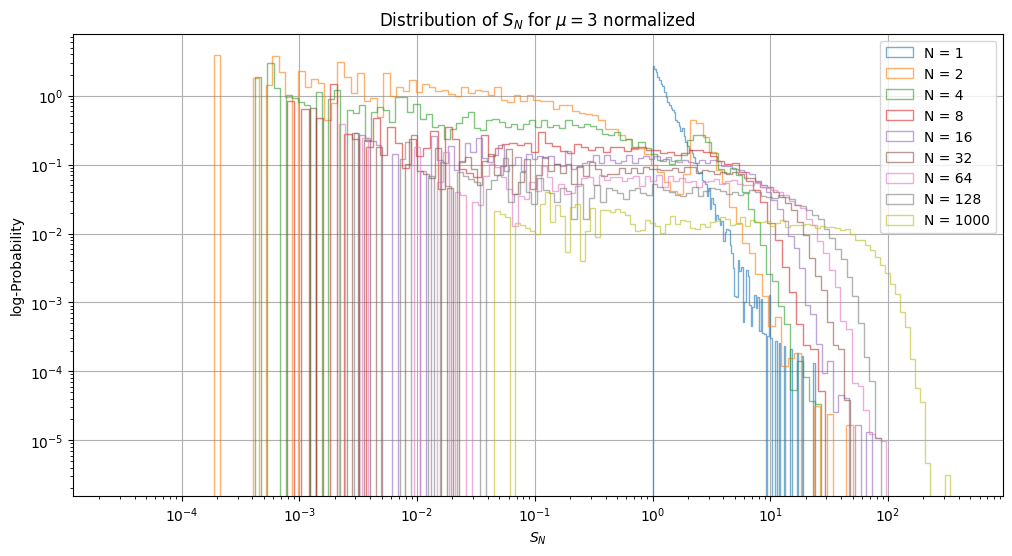

In [40]:
plt.figure(figsize=(12, 6))
        # Genera molte somme S_N per un dato N
samples = 10000
N_values = [1,2,4,8,16,32,64,128,1000]
mu = 3
for N in N_values:
    S_values = []
    for _ in range(samples):
        values = []
        values = generate_N_numbers(mu,N)
        S_values.append(abs(np.sum(values)))
            
    bins = np.logspace(math.log(min(S_values),10),math.log(max(S_values),10), 100)
    plt.hist(S_values, bins=bins, density=True, alpha=0.6, label=f"N = {N}",histtype='step', stacked=True, fill=False)
        
plt.title(f"Distribution of $S_N$ for $\\mu = {mu}$ normalized")
plt.xlabel("$S_N$")
plt.ylabel("log-Probability")
plt.yscale("log")
plt.xscale("log")
plt.legend()
plt.grid()
plt.show()

3. Since we know that for $\mu = 3$ the $f(S,N)$ distribution converges to a Gaussian distribution with variance $\sqrt{N <x^2>}$, this means that the the exponents we need to go dimensionless are: $\gamma = \phi = \frac{1}{2}$.

4. Data collapse by rescaling:

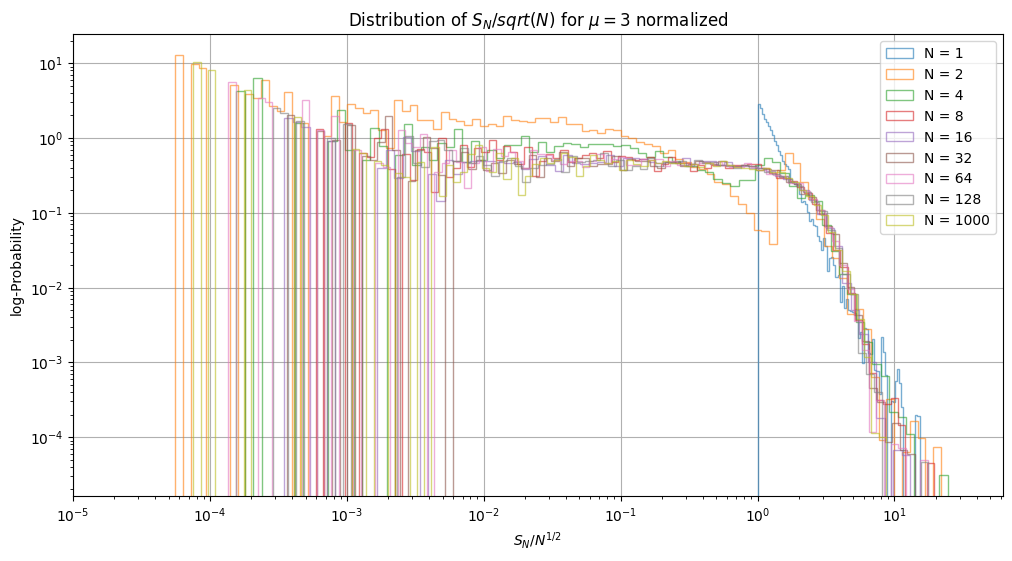

In [48]:
plt.figure(figsize=(12, 6))
        # Genera molte somme S_N per un dato N
samples = 10000
N_values = [1,2,4,8,16,32,64,128,1000]
mu = 3
for N in N_values:
    S_values = []
    for _ in range(samples):
        values = []
        values = generate_N_numbers(mu,N)
        S_values.append(abs(np.sum(values))/np.power(N,0.5))
            
    bins = np.logspace(math.log(min(S_values),10),math.log(max(S_values),10), 100)
    plt.hist(S_values, bins=bins, density=True, alpha=0.6, label=f"N = {N}",histtype='step', stacked=True, fill=False)
        
plt.title(f"Distribution of $S_N/sqrt(N)$ for $\\mu = {mu}$ normalized")
plt.xlabel("$S_N/N^{1/2}$")
plt.ylabel("log-Probability")
plt.yscale("log")
plt.xscale("log")
plt.legend()
plt.grid()
plt.show()

5. Since we're working with the parameter $\mu=3$, it means that both the mean and the second momentum exist, hence the Central Limit Theorem applies. From this we know that in the limit $N \to \infinity$, our distribution approaches the Gaussian distribution. If we're considering the dimensionless distribution, it'll approach the normal distribution.

6. From the paragraph 2.4 in the notes (more precisely from the three graphs presented), we know that $f(Z) \approx N^{\frac{2-\mu}{2}} Z^{-(1+\mu)}$. From this equation we immediately conclude that: $f(Z) \approx N^{-\frac{1}{2}} Z^{-4}$. Which means $\alpha = 1/2$ and $\beta = 4$.

7. Validation of the expetation

By looking at the graphs below, you can se the rescalings by N factors similar to the one we expect (varying the exponent alpha). I've plotted only "big" values of N to avoid confusion in the non limit regime. We can appreciate the precision of the collapsing for the value of alpha predicted by the theory ($\alpha = 0.5$).

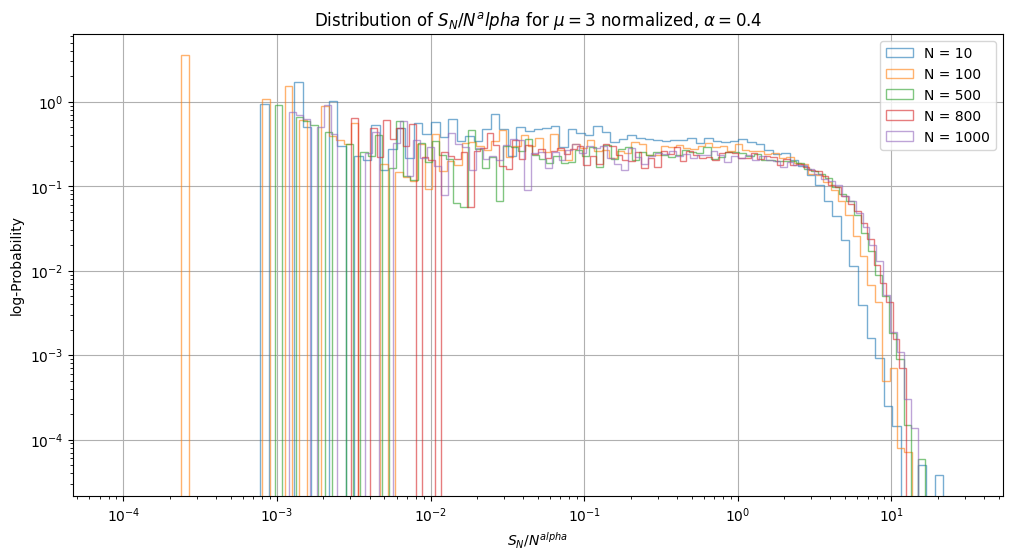

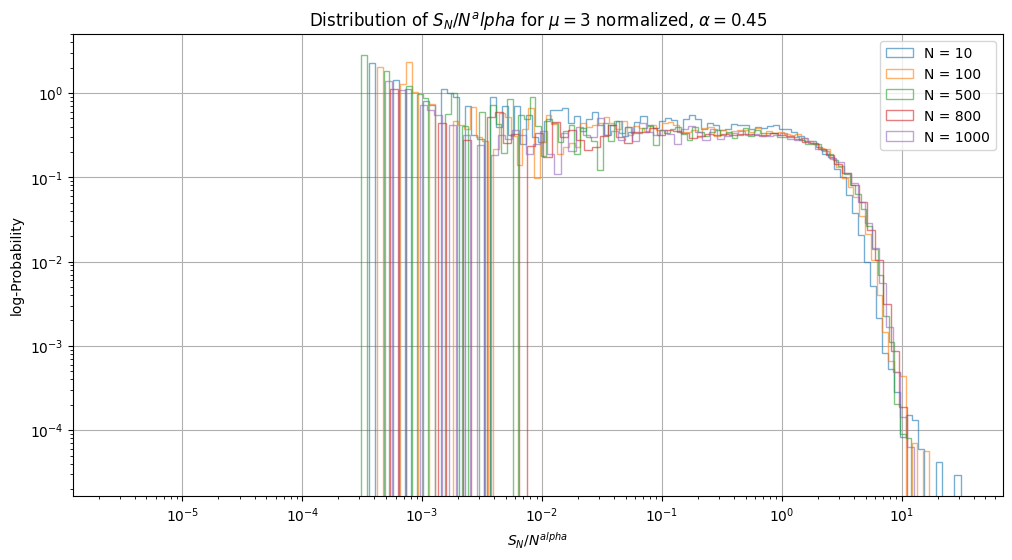

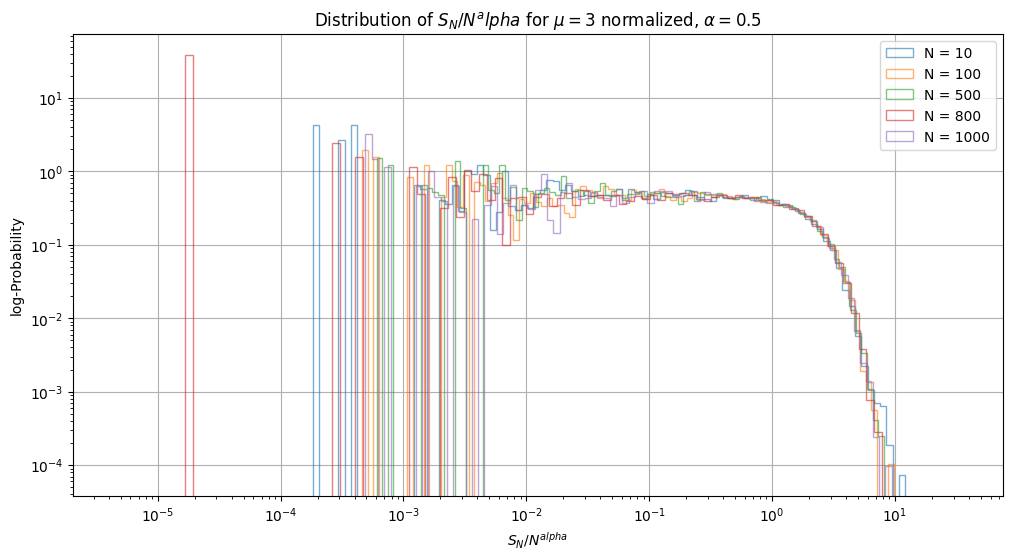

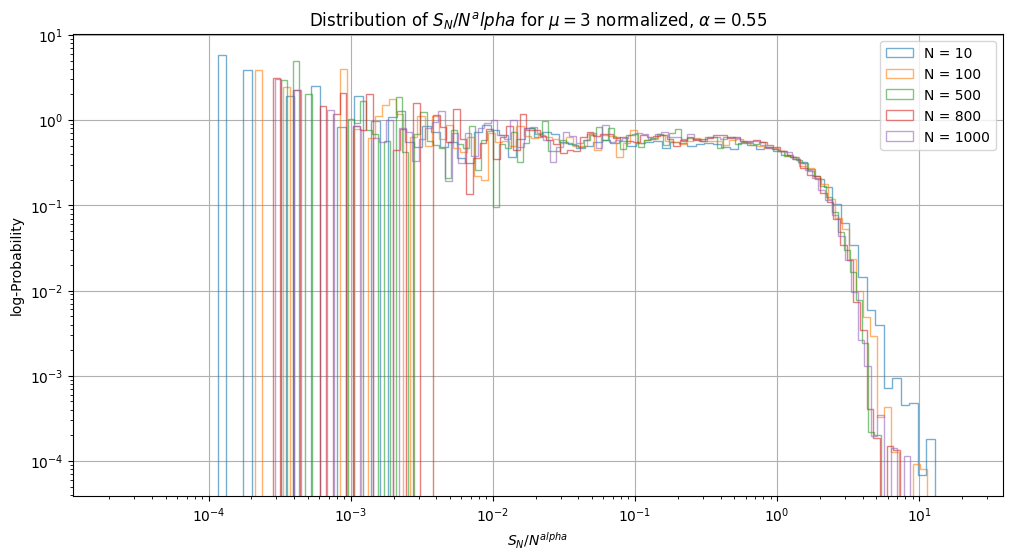

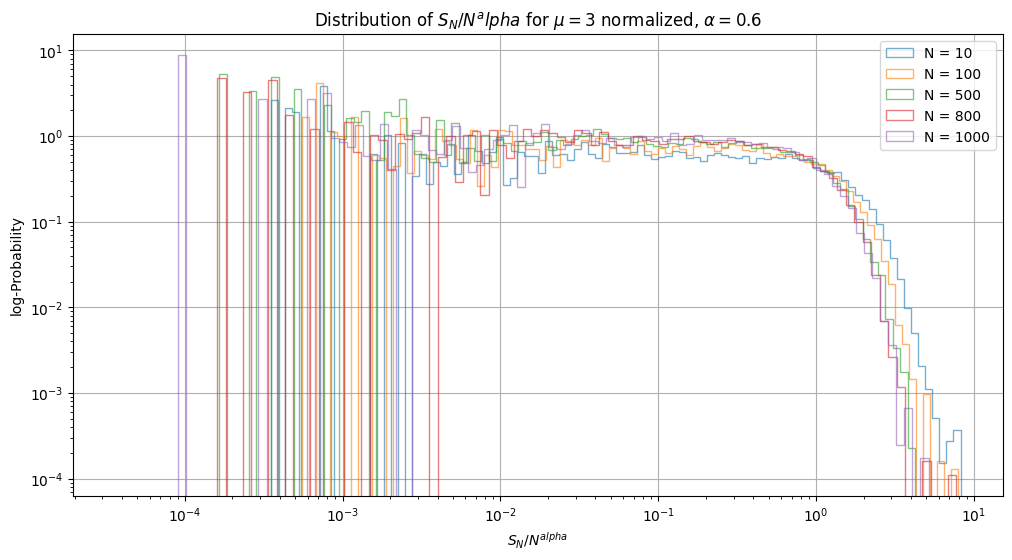

In [56]:
# Genera molte somme S_N per un dato N
samples = 10000
N_values = [10,100,500,800,1000]
mu = 3
alphas = [0.4,0.45,0.5,0.55,0.6]

for alpha in alphas:
    plt.figure(figsize=(12, 6))
    for N in N_values:
        S_values = []
        for _ in range(samples):
            values = []
            values = generate_N_numbers(mu,N)
            S_values.append(abs(np.sum(values))/np.power(N,alpha))
                
        bins = np.logspace(math.log(min(S_values),10),math.log(max(S_values),10), 100)
        plt.hist(S_values, bins=bins, density=True, alpha=0.6, label=f"N = {N}",histtype='step', stacked=True, fill=False)
            
    plt.title(f"Distribution of $S_N/N^alpha$ for $\\mu = {mu}$ normalized, $\\alpha = {alpha}$")
    plt.xlabel("$S_N/N^{alpha}$")
    plt.ylabel("log-Probability")
    plt.yscale("log")
    plt.xscale("log")
    plt.legend()
    plt.grid()
    plt.show()